<a href="https://colab.research.google.com/github/Rohan-Rajesh/ViT_replication/blob/main/ViT_replication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Recreating the original ViT model architecuture from this paper: https://arxiv.org/abs/2010.11929

In [ ]:
!pip install -q torchinfo

In [ ]:
import torch
import torchvision
from torch import nn
from torchvision import transforms
from torchinfo import summary
import matplotlib.pyplot as plt

print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


In [ ]:
!git clone https://github.com/mrdbourke/pytorch-deep-learning
!mv pytorch-deep-learning/going_modular .
!mv pytorch-deep-learning/helper_functions.py .
!rm -rf pytorch-deep-learning
from going_modular.going_modular import data_setup, engine
from helper_functions import download_data, set_seeds, plot_loss_curves

Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4400 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 19.48 MiB/s, done.
Resolving deltas: 100% (2662/2662), done.
Updating files: 100% (248/248), done.


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")

train_dir = image_path / "train"
test_dir = image_path / "test"

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


In [ ]:
custom_transforms = transforms.Compose([
    transforms.Resize([224, 224]), # described in paper hyperparameters
    transforms.ToTensor()
])

BATCH_SIZE = 32 # single gpu based batch size

train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
  train_dir=train_dir,
  test_dir=test_dir,
  transform=custom_transforms,
  batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7b78bd2e68d0>,
 ['pizza', 'steak', 'sushi'])

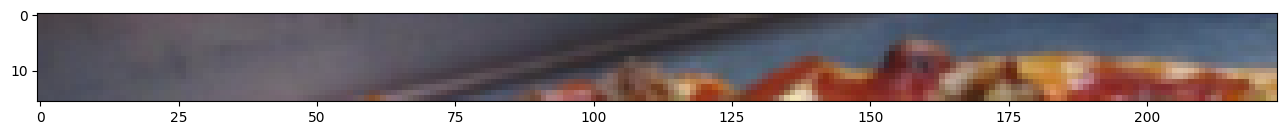

In [ ]:
img_batch, label_batch = next(iter(train_dataloader))
image_permuted = img_batch[0].permute(1, 2, 0)
patch_size = 16

plt.figure(figsize=(patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :])

In [ ]:
img_size = 224
patch_size = 16
num_patches = img_size / patch_size

fig, axs = plt.subplots(ncols=img_size // patch_size,
                        nrows=img_size // patch_size,
                        figsize=(img_size, img_size),
                        sharex=True,
                        sharey=True)

for i, row_patch in enumerate(range(0, img_size, patch_size)):
  for j, column_patch in enumerate(range(0, img_size, patch_size)):
    axs[i, j].imshow(image_permuted[column_patch:column_patch+patch_size, row_patch:row_patch+patch_size, :]);
    axs[i, j].set_ylabel(i+1, rotation="horizontal", horizontalalignment="right", verticalalignment="center")
    axs[i, j].set_xlabel(j+1)
    axs[i, j].set_xticks([])
    axs[i, j].set_yticks([])
    axs[i, j].label_outer()



In [ ]:
# create a convolutional layer to create patches and flatten to a 1d vector
# kernel: size of each patch (16 x 16)
# stride: the step value to move to the next kernel (16)

conv2d = nn.Conv2d(
    in_channels=3,
    out_channels=768, # hyperparameter
    kernel_size=16,
    stride=16,
    padding=0
)

# unsqueeze adds batch dimension (how many images are we passing in at once)
conv_embedding = conv2d(img_batch[0].unsqueeze(0))
conv_embedding.shape

torch.Size([1, 768, 14, 14])

Showing random convolutional feature maps from indexes: [760, 467, 356, 640, 569]


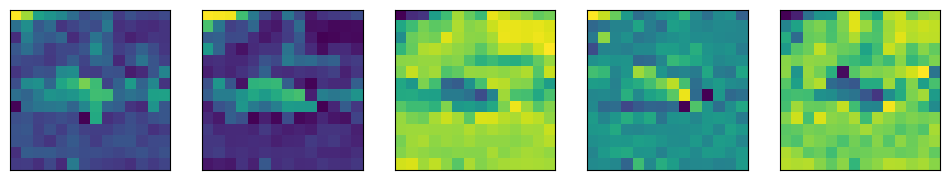

In [ ]:
import random
random_indexes = random.sample(range(0, 768), k=5) # pick 5 numbers between 0 and the embedding size
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

# Create plot
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 12))

# Plot random image feature maps
for i, idx in enumerate(random_indexes):
    image_conv_feature_map = conv_embedding[:, idx, :, :] # index on the output tensor of the convolutional layer
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[]);

In [ ]:
flatten_dims = nn.Flatten(start_dim=2, end_dim=3)
flattened_embedding = flatten_dims(conv_embedding)
flattened_embedding.shape

torch.Size([1, 768, 196])

In [ ]:
batch_size = 1
patch_embedding_size = 768

In [ ]:
# putting the conv2d -> flatten into a single nn.Sequential layer
class PatchEmbedding(nn.Module):
  def __init__(self,
               in_channels:int=3,
               out_channels:int=768,
               kernel_size:int=16,
               stride:int=16,
               padding:int=0,
               flatten_start_dim:int=2,
               flatten_end_dim:int=3):
    super().__init__()

    self.conv2d = nn.Conv2d(in_channels=in_channels,
                            out_channels=out_channels,
                            kernel_size=kernel_size,
                            stride=stride,
                            padding=padding)
    self.flatten = nn.Flatten(start_dim=flatten_start_dim, end_dim=flatten_end_dim)

  def forward(self, x):
    flattened_emb = self.flatten(self.conv2d(x))
    return flattened_emb.permute(0, 2, 1)

patch_embedding = PatchEmbedding()
flattened_embedding = patch_embedding(img_batch[0].unsqueeze(0))
flattened_embedding.shape

torch.Size([1, 196, 768])

In [ ]:
# creating and prepending the class token to dim=1 of each image
cls_token = nn.Parameter(torch.randn(batch_size, 1, patch_embedding_size), requires_grad=True)
embedding_with_cls = torch.cat((cls_token, final_embedding), dim=1)
embedding_with_cls.shape

torch.Size([1, 197, 768])

In [ ]:
# create positional embedding and broadcast/add it to the image embeddings
positional_embeddings = nn.Parameter(torch.randn((embedding_with_cls.shape[1], embedding_with_cls.shape[2]), requires_grad=True))
embedding_cls_position = embedding_with_cls + positional_embeddings
embedding_cls_position

tensor([[[ 0.2807, -1.1991, -1.9394,  ..., -0.6506, -0.7404, -1.9315],
         [ 0.6764,  1.9024,  0.0338,  ...,  0.5434,  1.7736, -2.2951],
         [-0.1472, -0.5279,  0.0727,  ..., -1.6675,  1.1339, -0.9928],
         ...,
         [-1.9588,  1.4252, -1.1395,  ...,  0.7473,  1.0445,  1.2237],
         [ 1.8926, -1.6878, -0.8816,  ..., -0.9176,  1.2321,  2.2095],
         [-0.3008,  0.1114, -0.4599,  ...,  0.6382,  0.1201, -1.4499]]],
       grad_fn=<AddBackward0>)

In [ ]:
# reinitializing this class for better readability
# putting the conv2d -> flatten into a single nn.Sequential layer
class PatchEmbedding(nn.Module):
  def __init__(self,
               in_channels:int=3,
               out_channels:int=768,
               kernel_size:int=16,
               stride:int=16,
               padding:int=0,
               flatten_start_dim:int=2,
               flatten_end_dim:int=3):
    super().__init__()

    self.conv2d = nn.Conv2d(in_channels=in_channels,
                            out_channels=out_channels,
                            kernel_size=kernel_size,
                            stride=stride,
                            padding=padding)
    self.flatten = nn.Flatten(start_dim=flatten_start_dim, end_dim=flatten_end_dim)

  def forward(self, x):
    flattened_emb = self.flatten(self.conv2d(x))
    return flattened_emb.permute(0, 2, 1)

patch_embedding = PatchEmbedding()
flattened_embedding = patch_embedding(img_batch[0].unsqueeze(0))
flattened_embedding.shape

In [ ]:
class MSABlock(nn.Module):
  def __init__(self, embedding_dim:int=768, num_heads:int=12, dropout_rate:float=0.0):
    super().__init__()
    self.layerNorm = nn.LayerNorm(normalized_shape=embedding_dim)
    self.msa = nn.MultiheadAttention(embed_dim=embedding_dim, num_heads=num_heads, dropout=dropout_rate, batch_first=True)

  def forward(self, x):
    normalized_embedding = self.layerNorm(x)
    attn_output, _ = self.msa(query=normalized_embedding,
                              key=normalized_embedding,
                              value=normalized_embedding,
                              need_weights=False)

    return attn_output

In [ ]:
msa_block = MSABlock()
msa_output = msa_block(embedding_cls_position)
msa_output

tensor([[[-0.0416,  0.0284,  0.1146,  ...,  0.0690, -0.2193, -0.1589],
         [-0.0335,  0.0477,  0.0924,  ...,  0.0801, -0.2207, -0.1560],
         [-0.0308,  0.0268,  0.0934,  ...,  0.0786, -0.2114, -0.1752],
         ...,
         [-0.0745,  0.0681,  0.1182,  ...,  0.0459, -0.2327, -0.1267],
         [-0.0431,  0.0338,  0.1254,  ...,  0.0926, -0.2614, -0.1394],
         [-0.0393,  0.0409,  0.0912,  ...,  0.0856, -0.2077, -0.1573]]],
       grad_fn=<TransposeBackward0>)

In [ ]:
class MLPBlock(nn.Module):
  def __init__(self, patch_embedding_size:int=768, mlp_size:int=3072, dropout_rate:float=0.1):
    super().__init__()
    self.layerNorm = nn.LayerNorm(normalized_shape=patch_embedding_size)
    self.mlp = nn.Sequential(
      nn.Linear(in_features=patch_embedding_size, out_features=mlp_size),
      nn.GELU(),
      nn.Dropout(p=dropout_rate),
      nn.Linear(in_features=mlp_size, out_features=patch_embedding_size),
      nn.Dropout(p=dropout_rate)
    )

  def forward(self, x):
    normalized_emb = self.layerNorm(x)
    return self.mlp(normalized_emb)

In [ ]:
mlp_block = MLPBlock()
mlp_output = mlp_block(msa_output)
mlp_output.shape

torch.Size([1, 197, 768])

In [ ]:
class TransformerEncoderBlock(nn.Module):
  def __init__(self,
               patch_embedding_size:int=768,
               msa_num_heads:int=12,
               msa_dropout_rate:float=0.0,
               mlp_size:int=3072,
               mlp_dropout_rate:float=0.1):
    super().__init__()

    self.msa_block = MSABlock(embedding_dim=patch_embedding_size, num_heads=msa_num_heads, dropout_rate=msa_dropout_rate)
    self.mlp_block = MLPBlock(patch_embedding_size=patch_embedding_size, mlp_size=mlp_size, dropout_rate=mlp_dropout_rate)

  def forward(self, x):
    x = self.msa_block(x) + x
    x = self.mlp_block(x) + x

    return x

In [ ]:
transformer_encoder_block = TransformerEncoderBlock()

# Print an input and output summary of our Transformer Encoder (uncomment for full output)
summary(model=transformer_encoder_block,
        input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderBlock (TransformerEncoderBlock)  [1, 197, 768]        [1, 197, 768]        --                   True
├─MSABlock (msa_block)                             [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layerNorm)                       [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (msa)                    --                   [1, 197, 768]        2,362,368            True
├─MLPBlock (mlp_block)                             [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layerNorm)                       [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp)                            [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                     

In [ ]:
class ViT(nn.Module):
  def __init__(self,
               img_size:int=224,
               in_channels:int=3,
               patch_size:int=16,
               embedding_dim:int=768,
               embedding_dropout_rate=0.1,
               num_transformer_layers:int=12,
               num_msa_heads:int=12,
               msa_dropout_rate:float=0.0,
               mlp_size=3072,
               mlp_dropout_rate=0.1,
               num_classes=1000):
    super().__init__()

    assert img_size % patch_size == 0, f"Image size must be divisible by patch size, image size: {img_size}, patch size: {patch_size}."

    # splitting the image into patches
    self.num_patches = (img_size * img_size) / (patch_size * patch_size)
    self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim), requires_grad=True)
    self.positional_embedding = nn.Parameter(torch.randn((num_patches + 1, embedding_dim)))

    self.embedding_dropout = nn.Dropout(p=embedding_dropout_rate)

    self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                          out_channels=embedding_dim,
                                          patch_size=patch_size,
                                          kernel_size=patch_size,
                                          stride=patch_size)

    # initializing 12 layers of the transformer encoder
    self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(patch_embedding_size=embedding_dim,
                                                       msa_num_heads=num_msa_heads,
                                                       msa_dropout_rate=msa_dropout_rate,
                                                       mlp_size=mlp_size,
                                                       mlp_dropout_rate=mlp_dropout_rate) for _ in range(num_transformer_layers)])

    # final mlp head
    self.mlp_head = nn.Sequential(
        nn.LayerNorm(normalized_shape=embedding_dim),
        nn.Linear(in_features=embedding_dim, out_features=num_classes)
    )

  def forward(self, x):
    batch_size = x.shape[0]

    class_token = self.class_embedding.expand(batch_size, -1, -1)
    x = self.patch_embedding(x)
    x = torch.cat((class_token, x), dim=1)
    x = x + self.positional_embedding
    x = self.embedding_dropout()

    x = self.transformer_encoder(x)
    x = self.mlp_head(x[:, 0])

    return x